Phase 1: Dataset Preparation

In [1]:
!pip install pycocotools tensorflow pillow tqdm requests scikit-learn

Step 2: Import Libraries

In [2]:
import os
import random
import zipfile
import requests
import shutil
from tqdm import tqdm
from PIL import Image
from io import BytesIO

import numpy as np
import tensorflow as tf
from pycocotools.coco import COCO
from sklearn.model_selection import train_test_split

Step 3: Download COCO Annotations Only

In [3]:
!mkdir -p coco

annotation_url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
annotation_zip = "coco/annotations_trainval2017.zip"

if not os.path.exists(annotation_zip):
    !wget -O coco/annotations_trainval2017.zip http://images.cocodataset.org/annotations/annotations_trainval2017.zip

with zipfile.ZipFile(annotation_zip, 'r') as zip_ref:
    zip_ref.extractall("coco")

--2026-05-19 14:29:49--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 54.231.162.225, 52.216.221.233, 16.15.183.212, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|54.231.162.225|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘coco/annotations_trainval2017.zip’

coco/annotations_tr 100%[===================>] 241.19M  62.3MB/s    in 4.3s    

2026-05-19 14:29:54 (56.0 MB/s) - ‘coco/annotations_trainval2017.zip’ saved [252907541/252907541]



Step 4: Select 25 COCO Categories

In [4]:
selected_classes = [
    "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light",
    "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack",
    "umbrella", "handbag", "tie", "suitcase", "sports ball"
]

IMAGES_PER_CLASS = 100
MIN_AREA = 2000

Step 5: Load COCO Annotations

In [5]:
ann_file = "coco/annotations/instances_train2017.json"
coco = COCO(ann_file)

cat_ids = coco.getCatIds(catNms=selected_classes)
cats = coco.loadCats(cat_ids)

cat_id_to_name = {cat["id"]: cat["name"] for cat in cats}
name_to_cat_id = {cat["name"]: cat["id"] for cat in cats}

print("Selected classes:")
print(cat_id_to_name)

loading annotations into memory...
Done (t=13.07s)
creating index...
index created!
Selected classes:
{1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane', 6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light', 17: 'cat', 18: 'dog', 19: 'horse', 20: 'sheep', 21: 'cow', 22: 'elephant', 23: 'bear', 24: 'zebra', 25: 'giraffe', 27: 'backpack', 28: 'umbrella', 31: 'handbag', 32: 'tie', 33: 'suitcase', 37: 'sports ball'}


Step 6: Download and Crop 100 Objects Per Class

In [6]:
output_dir = "smartvision_dataset_raw"

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

os.makedirs(output_dir, exist_ok=True)

def download_image(url):
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        return Image.open(BytesIO(response.content)).convert("RGB")
    except:
        return None

for class_name in selected_classes:
    print(f"\nProcessing class: {class_name}")

    class_dir = os.path.join(output_dir, class_name.replace(" ", "_"))
    os.makedirs(class_dir, exist_ok=True)

    cat_id = name_to_cat_id[class_name]
    ann_ids = coco.getAnnIds(catIds=[cat_id], iscrowd=False)
    anns = coco.loadAnns(ann_ids)

    anns = [ann for ann in anns if ann["area"] >= MIN_AREA]
    random.shuffle(anns)

    saved_count = 0
    used_images = set()

    for ann in tqdm(anns):
        if saved_count >= IMAGES_PER_CLASS:
            break

        img_id = ann["image_id"]

        if img_id in used_images:
            continue

        img_info = coco.loadImgs(img_id)[0]
        img_url = img_info["coco_url"]

        image = download_image(img_url)

        if image is None:
            continue

        x, y, w, h = ann["bbox"]
        x, y, w, h = int(x), int(y), int(w), int(h)

        if w < 30 or h < 30:
            continue

        crop = image.crop((x, y, x + w, y + h))

        save_path = os.path.join(
            class_dir,
            f"{class_name.replace(' ', '_')}_{saved_count}.jpg"
        )

        crop.save(save_path)
        used_images.add(img_id)
        saved_count += 1

    print(f"Saved {saved_count} images for {class_name}")


Processing class: person


  0%|          | 100/123720 [00:48<16:45:11,  2.05it/s]


Saved 100 images for person

Processing class: bicycle


  3%|▎         | 102/3141 [00:48<24:08,  2.10it/s]


Saved 100 images for bicycle

Processing class: car


...

Saved 100 images for tie

Processing class: suitcase


  3%|▎         | 106/4094 [00:46<29:07,  2.28it/s]


Saved 100 images for suitcase

Processing class: sports ball


 21%|██▏       | 103/482 [00:47<02:54,  2.18it/s]

Saved 100 images for sports ball


Step 7: Create Train, Validation, and Test Folders

In [7]:
base_dir = "smartvision_dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

for split_dir in [train_dir, val_dir, test_dir]:
    os.makedirs(split_dir, exist_ok=True)

for class_name in os.listdir(output_dir):
    class_path = os.path.join(output_dir, class_name)
    images = os.listdir(class_path)

    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    for split_name, split_imgs in [
        ("train", train_imgs),
        ("val", val_imgs),
        ("test", test_imgs)
    ]:
        split_class_dir = os.path.join(base_dir, split_name, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        for img in split_imgs:
            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_dir, img)
            shutil.copy(src, dst)

print("Dataset prepared successfully.")

Dataset prepared successfully.


Step 8: Load Dataset for Training

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)
print("Number of classes:", num_classes)

Found 1750 files belonging to 25 classes.
Found 375 files belonging to 25 classes.
Found 375 files belonging to 25 classes.
['airplane', 'backpack', 'bear', 'bicycle', 'boat', 'bus', 'car', 'cat', 'cow', 'dog', 'elephant', 'giraffe', 'handbag', 'horse', 'motorcycle', 'person', 'sheep', 'sports_ball', 'suitcase', 'tie', 'traffic_light', 'train', 'truck', 'umbrella', 'zebra']
Number of classes: 25


Step 9: Optimize Dataset Loading

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Step 10: Build Fast Transfer Learning Model

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

IMG_SIZE = 224
EPOCHS = 15

models_to_train = {
    "VGG16": tf.keras.applications.VGG16,
    "ResNet50": tf.keras.applications.ResNet50,
    "MobileNetV2": tf.keras.applications.MobileNetV2,
    "EfficientNetB0": tf.keras.applications.EfficientNetB0
}

preprocess_functions = {
    "VGG16": tf.keras.applications.vgg16.preprocess_input,
    "ResNet50": tf.keras.applications.resnet50.preprocess_input,
    "MobileNetV2": tf.keras.applications.mobilenet_v2.preprocess_input,
    "EfficientNetB0": tf.keras.applications.efficientnet.preprocess_input
}

histories = {}
results = {}
trained_models = {}

Step 11: Create Model Building Function

In [12]:
def build_transfer_model(model_name, base_model_function):
    print(f"\nBuilding model: {model_name}")

    base_model = base_model_function(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
    ])

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = data_augmentation(inputs)
    x = preprocess_functions[model_name](x)
    x = base_model(x, training=False)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

Step 12: Train All Four Models

In [13]:
for model_name, base_model_function in models_to_train.items():
    print("=" * 60)
    print(f"Training {model_name}")
    print("=" * 60)

    model = build_transfer_model(model_name, base_model_function)

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True
    )

    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        f"{model_name}_best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[early_stop, checkpoint]
    )

    test_loss, test_accuracy = model.evaluate(test_ds)

    histories[model_name] = history
    results[model_name] = {
        "Test Loss": test_loss,
        "Test Accuracy": test_accuracy
    }
    trained_models[model_name] = model

    print(f"{model_name} Test Accuracy: {test_accuracy:.4f}")

Training VGG16

Building model: VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 263ms/step - accuracy: 0.1074 - loss: 8.5098 - val_accuracy: 0.2880 - val_loss: 4.6602
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 169ms/step - accuracy: 0.2749 - loss: 4.8616 - val_accuracy: 0.4480 - val_loss: 2.9644
Epoch 3/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.3931 - loss: 3.6292 - val_accuracy: 0.5600 - val_loss: 2.2682
Epoch 4/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.4543 - loss: 2.8692 - val_accuracy: 0.5947 - val_loss: 1.9988
Epoch 5/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - accuracy: 0.5160 - loss: 2.4638 - val_accuracy: 0.6213 - val_loss: 1.8312
Epoch 6/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.5491 - loss: 2.1584 - val_accuracy: 0.6587 - val_loss: 1.7738
Epoch 7/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - accuracy: 0.5594 - loss: 2.0458 - val_accuracy: 0.6693 - val_loss: 1.6525
Epoch 8/15

Step 13: Compare All Model Results

In [14]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test Accuracy", ascending=False)

print(results_df)

                Test Loss  Test Accuracy
EfficientNetB0   0.646596       0.813333
ResNet50         0.858393       0.754667
MobileNetV2      0.983172       0.709333
VGG16            1.849996       0.664000



Step 14: Plot Model Accuracy Comparison

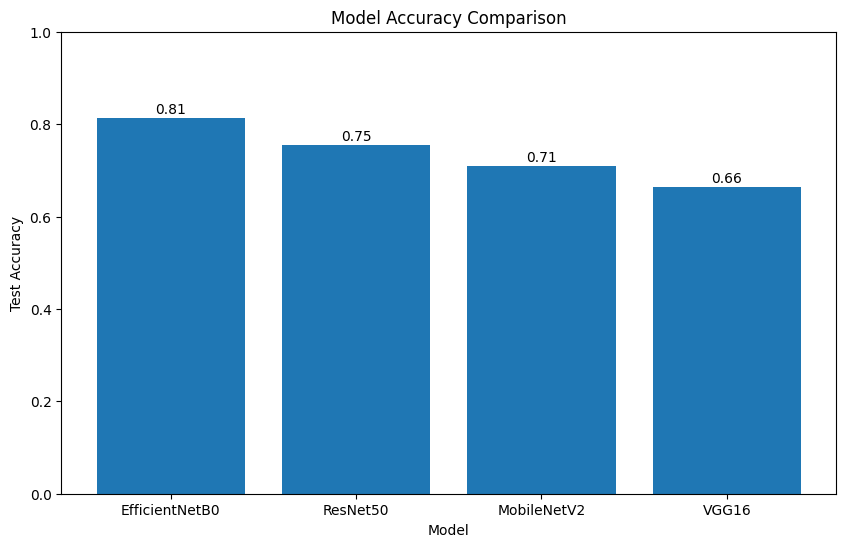

In [15]:
plt.figure(figsize=(10, 6))
plt.bar(results_df.index, results_df["Test Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

for index, value in enumerate(results_df["Test Accuracy"]):
    plt.text(index, value + 0.01, f"{value:.2f}", ha="center")

plt.show()

Step 15: Plot Training and Validation Accuracy

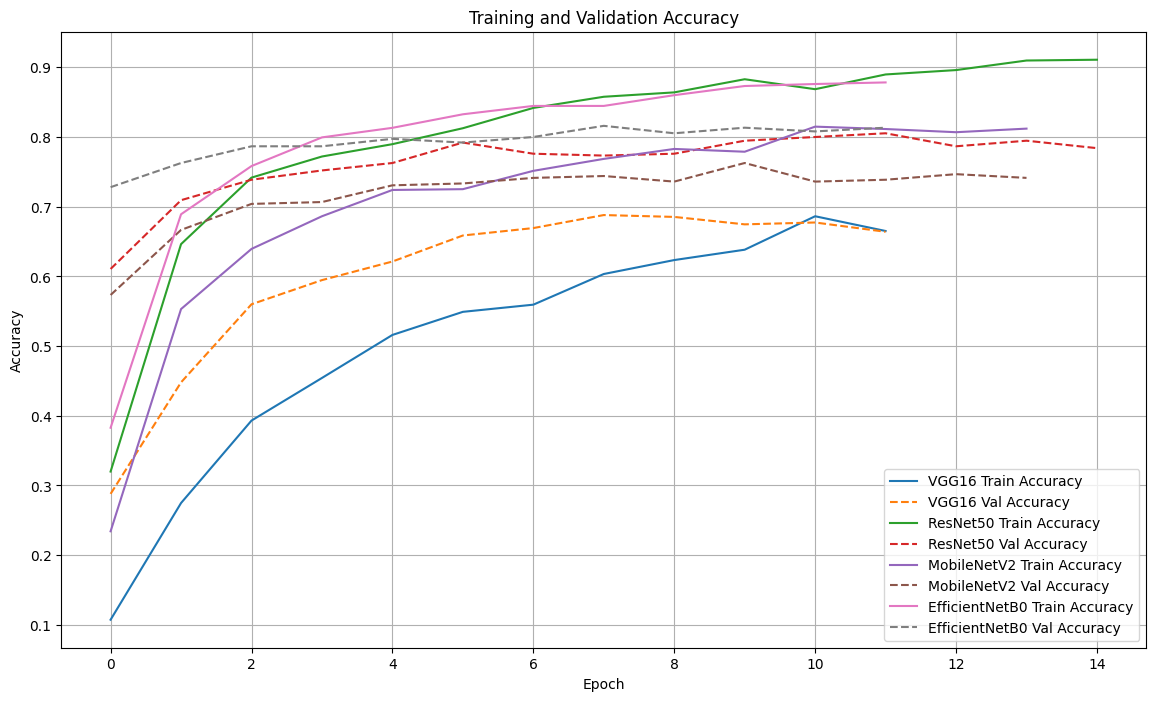

In [16]:
plt.figure(figsize=(14, 8))

for model_name, history in histories.items():
    plt.plot(history.history["accuracy"], label=f"{model_name} Train Accuracy")
    plt.plot(history.history["val_accuracy"], linestyle="--", label=f"{model_name} Val Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Step 16: Plot Training and Validation Loss

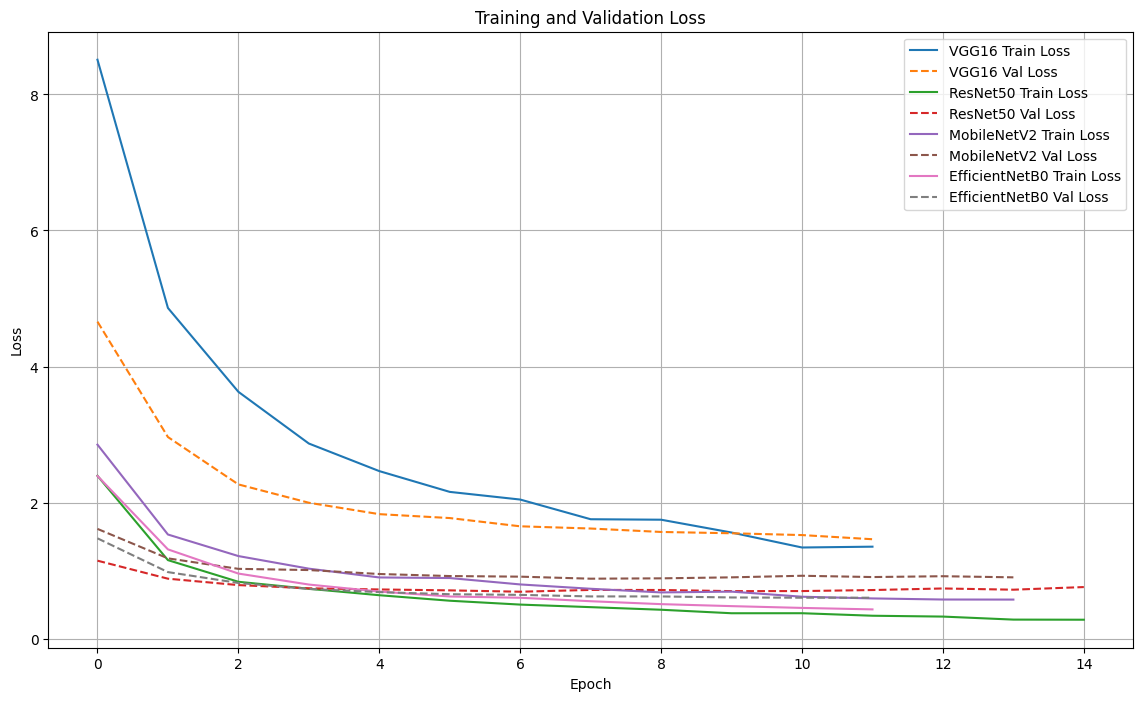

In [17]:
plt.figure(figsize=(14, 8))

for model_name, history in histories.items():
    plt.plot(history.history["loss"], label=f"{model_name} Train Loss")
    plt.plot(history.history["val_loss"], linestyle="--", label=f"{model_name} Val Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Step 17: Save the Best Model

In [18]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)
print("Best Test Accuracy:", results_df.loc[best_model_name, "Test Accuracy"])

best_model.save("smartvision_best_25class_model.keras")

with open("class_names.txt", "w") as f:
    for class_name in class_names:
        f.write(class_name + "\n")

print("Best model and class names saved successfully.")

Best Model: EfficientNetB0
Best Test Accuracy: 0.8133333325386047
Best model and class names saved successfully.


Step 18: Fine-Tune the Best Model

In [19]:
best_base_model = None

for layer in best_model.layers:
    if isinstance(layer, tf.keras.Model):
        best_base_model = layer
        break

if best_base_model is not None:
    best_base_model.trainable = True

    for layer in best_base_model.layers[:-30]:
        layer.trainable = False

    best_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    fine_tune_history = best_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_accuracy",
                patience=4,
                restore_best_weights=True
            ),
            tf.keras.callbacks.ModelCheckpoint(
                "smartvision_finetuned_best_model.keras",
                monitor="val_accuracy",
                save_best_only=True
            )
        ]
    )

    fine_tune_loss, fine_tune_accuracy = best_model.evaluate(test_ds)

    print("Fine-Tuned Best Model:", best_model_name)
    print("Fine-Tuned Test Accuracy:", fine_tune_accuracy)

    best_model.save("smartvision_final_finetuned_model.keras")
else:
    print("Base model not found for fine-tuning.")

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 21s 188ms/step - accuracy: 0.8606 - loss: 0.5216 - val_accuracy: 0.8107 - val_loss: 0.6216
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - accuracy: 0.8583 - loss: 0.5135 - val_accuracy: 0.8133 - val_loss: 0.6189
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.8726 - loss: 0.4879 - val_accuracy: 0.8133 - val_loss: 0.6162
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.8697 - loss: 0.4877 - val_accuracy: 0.8133 - val_loss: 0.6145
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.8589 - loss: 0.4945 - val_accuracy: 0.8133 - val_loss: 0.6139
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.8674 - loss: 0.4775 - val_accuracy: 0.8160 - val_loss: 0.6126
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.8709 - loss: 0.4767 - val_accuracy: 0.8133 - val_loss: 0.6117
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.8749 - loss: 0.4690 - val_accuracy: 0.8

Step 19: Predict Uploaded Image

Saving jack-russell-terrier-running-in-the-field-portrait-of-a-dog-ai-generated-free-photo.jpg to jack-russell-terrier-running-in-the-field-portrait-of-a-dog-ai-generated-free-photo.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


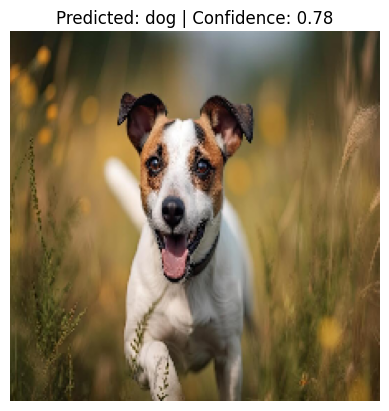

In [21]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for file_name in uploaded.keys():
    img = tf.keras.utils.load_img(file_name, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    prediction = best_model.predict(img_array)
    predicted_index = np.argmax(prediction)
    confidence = np.max(prediction)

    predicted_class = class_names[predicted_index]

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_class} | Confidence: {confidence:.2f}")
    plt.show()

Step 20: Download Final Model

In [22]:
from google.colab import files

files.download("smartvision_final_finetuned_model.keras")
files.download("smartvision_best_25class_model.keras")
files.download("class_names.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Save All Trained Models to Google Drive

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
import os
import json
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/SmartVisionAI"
MODEL_DIR = f"{PROJECT_DIR}/models"

os.makedirs(MODEL_DIR, exist_ok=True)

# Save all trained models
for model_name, model in trained_models.items():
    save_path = f"{MODEL_DIR}/{model_name}_smartvision.keras"
    model.save(save_path)
    print(f"Saved: {save_path}")

# Save class names
with open(f"{MODEL_DIR}/class_names.txt", "w") as f:
    for class_name in class_names:
        f.write(class_name + "\n")

# Save model results
results_df.to_csv(f"{MODEL_DIR}/model_comparison_results.csv")

print("All models, class names, and results saved to Google Drive.")

Saved: /content/drive/MyDrive/SmartVisionAI/models/VGG16_smartvision.keras
Saved: /content/drive/MyDrive/SmartVisionAI/models/ResNet50_smartvision.keras
Saved: /content/drive/MyDrive/SmartVisionAI/models/MobileNetV2_smartvision.keras
Saved: /content/drive/MyDrive/SmartVisionAI/models/EfficientNetB0_smartvision.keras
All models, class names, and results saved to Google Drive.
